# Space Launch - Integration of Three Datasets

**Notebook 3** - Data Merging Phase

## Purpose
Merge the three cleaned TSV files into one complete dataset for downstream analysis. Performs merge using launch ID as the primary key.

## Authors
- **Phillip Roman** - Data integration and merge
- **Team Contributors:**
  - Jillian Kunze - Rocket parameters
  - Innocent Gumunyu - Launch parameters
  - Phillip Roman - Mission parameters
  - Ryan Peters - GitHub Management

## Workflow Position
1. Data Collection → Raw launch data collected via API
2. Data Cleaning → Extract parameters from raw data:
   - 2a. Extract rocket parameters
   - 2b. Extract launch parameters
   - 2c. Extract mission parameters
3. **This Notebook** → Merge all cleaned datasets

## Merge Strategy
- **Primary key:** Launch ID column (standardized across all datasets)
- **Merge type:** Outer join to preserve all records
- **Two-step merge:** first Rocket + Launch, then add Mission data

## Input Files
- `clean_rocket_data.tsv` - 15 rocket attributes
- `clean_launch_data.tsv` - 16 launch attributes  
- `clean_mission_data.tsv` - 10 mission attributes

## Output
- `merged_launch_data.tsv` - Complete dataset with 39 attributes ready for analysis

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


## Import Required Libraries and Load Cleaned Data Files

Load pandas for DataFrame operations and merging.

Load the three TSV files from rocket, launch, and mission cleanings.

If using Google Colab, adjust commented code as necessary.

### Expected Files:
- `clean_rocket_data.tsv` - Rocket specifications and manufacturer info
- `clean_launch_data.tsv` - Launch location, timing, and status
- `clean_mission_data.tsv` - Mission objectives and orbit details

In [2]:
import pandas as pd
import os

In [3]:
rocket_path = os.path.join("..", "data", "cleaned data", "clean_rocket_data.tsv")
launch_path = os.path.join("..", "data", "cleaned data", "clean_launch_data.tsv")
mission_path = os.path.join("..", "data", "cleaned data", "clean_mission_data.tsv")

rocket_df = pd.read_csv(rocket_path, sep='\t')
launch_df = pd.read_csv(launch_path, sep='\t')
mission_df = pd.read_csv(mission_path, sep='\t')

print("Rocket data:", rocket_df.shape)
print("Launch data:", launch_df.shape)
print("Mission data:", mission_df.shape)

Rocket data: (7336, 15)
Launch data: (7336, 16)
Mission data: (7336, 10)


In [5]:
# import pandas as pd

# data_folder = '/content/drive/MyDrive/DSCI511/Term Project/'

# rocket_df = pd.read_csv(data_folder + 'clean_rocket_data.tsv', sep='\t')
# launch_df = pd.read_csv(data_folder + 'clean_launch_data.tsv', sep='\t')
# mission_df = pd.read_csv(data_folder + 'clean_mission_data.tsv', sep='\t')

# print("Rocket data:", rocket_df.shape)
# print("Launch data:", launch_df.shape)
# print("Mission data:", mission_df.shape)

## Check Column Names

Check which columns are in each file and confirm ID columns match.

In [4]:
print("Rocket columns:", list(rocket_df.columns))
print("Launch columns:", list(launch_df.columns))
print("Mission columns:", list(mission_df.columns))

Rocket columns: ['ID', 'Rocket_name', 'Manufacturer_name', 'Manufacturer_country', 'Manufacturer_company_type', 'Reusability', 'Min_no_stages', 'Max_no_stages', 'Rocket_length', 'Rocket_diameter', 'Launch_cost', 'Liftoff_mass_tons', 'Liftoff_thrust_kN', 'Rocket_apogee', 'Payload_mass']
Launch columns: ['ID', 'Launch Name', 'Launch Date', 'Country', 'Location Name', 'Latitude', 'Longitude', 'Fail Reason', 'Location Launch Attempt Count', 'Location Launch Attempt Count Year', 'Pad', 'Pad Launch Attempt Count', 'Status', 'Timeline Stages', 'Window Start', 'Window End']
Mission columns: ['launch_id', 'mission_id', 'mission_name', 'mission_type', 'mission_description', 'orbit_name', 'orbit_abbrev', 'program_name', 'lsp_name', 'lsp_type']


## Check ID Column Names

Make sure ID columns match before merging - need to rename if different.

In [5]:
print("Rocket ID column:", rocket_df.columns[0])
print("Launch ID column:", launch_df.columns[0])
print("Mission ID column:", mission_df.columns[0])

Rocket ID column: ID
Launch ID column: ID
Mission ID column: launch_id


## Fix Mission ID Column Name

Mission file uses 'launch_id' but the other two use 'ID' - rename it to match.

In [6]:
mission_df.rename(columns={'launch_id': 'ID'}, inplace=True)

# recheck ID column names
print("Rocket ID column:", rocket_df.columns[0])
print("Launch ID column:", launch_df.columns[0])
print("Mission ID column:", mission_df.columns[0])

Rocket ID column: ID
Launch ID column: ID
Mission ID column: ID


## Merge Rocket and Launch Data

Combine rocket and launch DataFrames on ID column using outer join.

In [7]:
rocket_and_launch = pd.merge(rocket_df, launch_df, on='ID', how='outer')
print(f"After merging Rocket + Launch: {rocket_and_launch.shape}")

# visual check
print(rocket_and_launch.head())
print("\nTotal columns:", len(rocket_and_launch.columns))

After merging Rocket + Launch: (7336, 30)
                                     ID     Rocket_name Manufacturer_name  \
0  e3df2ecd-c239-472f-95e4-2b89b4f75800  Sputnik 8K74PS           Energia   
1  f8c9f344-a6df-4f30-873a-90fe3a7840b3  Sputnik 8K74PS           Energia   
2  535c1a09-97c8-4f96-bb64-6336d4bcb1fb        Vanguard               NaN   
3  1b9e28d0-c531-44b0-9b37-244e62a6d3f4          Juno-I          Chrysler   
4  48bc7deb-b2e1-46c2-ab63-0ce00fbd192b        Vanguard               NaN   

       Manufacturer_country Manufacturer_company_type  Reusability  \
0                    Russia                Government        False   
1                    Russia                Government        False   
2                       NaN                       NaN        False   
3  United States of America                Commercial        False   
4                       NaN                       NaN        False   

   Min_no_stages  Max_no_stages  Rocket_length  Rocket_diameter  ...  \
0 

## Second Merge: Add Mission Data

Merge mission DataFrame into the combined rocket+launch data.

In [17]:
final_df = pd.merge(rocket_and_launch, mission_df, on='ID', how='outer')
print(f"Final merged data: {final_df.shape}")

# visual recheck
print(final_df.head(3))

Final merged data: (7336, 39)
                                     ID     Rocket_name Manufacturer_name  \
0  e3df2ecd-c239-472f-95e4-2b89b4f75800  Sputnik 8K74PS           Energia   
1  f8c9f344-a6df-4f30-873a-90fe3a7840b3  Sputnik 8K74PS           Energia   
2  535c1a09-97c8-4f96-bb64-6336d4bcb1fb        Vanguard               NaN   

  Manufacturer_country Manufacturer_company_type  Reusability  Min_no_stages  \
0               Russia                Government        False            1.0   
1               Russia                Government        False            1.0   
2                  NaN                       NaN        False            3.0   

   Max_no_stages  Rocket_length  Rocket_diameter  ...            Window End  \
0            1.0            NaN              NaN  ...  1957-10-04T19:28:34Z   
1            1.0            NaN              NaN  ...  1957-11-03T02:30:00Z   
2            3.0           23.0             1.14  ...  1957-12-06T16:44:35Z   

   mission_id  mission_

## Save Merged Dataset

Export the final combined dataset containing all 39 rocket, launch, and mission attributes.

### Before Running:
Update `output_path` if you want to save somewhere other than the current directory (choose from 3 options).

In [9]:
# Save options
# option 1 - save to current directory
# output_path = ''

# option 2 (Colab users) - save to Google Drive
#output_path = '/content/drive/MyDrive/DSCI511/Term Project/'

# option 3 - save to specific local path
option_3 = True
output_path = os.path.join("..", "data", "cleaned data")

output_filename = 'merged_data.tsv'

if option_3:
    try:
        file_path = os.path.join(output_path, output_filename)
        final_df.to_csv(file_path, sep='\t', index=False)
        print(f"Successfully saved merged data to {file_path}")
        print(f"Final shape: {final_df.shape}")
        print(f"Total attributes: {len(final_df.columns)}")
    except Exception as e:
        print(f"Error saving file: {e}")

else:

    try:
        final_df.to_csv(output_path + output_filename, sep='\t', index=False)
        print(f"Successfully saved merged data to {output_path + output_filename}")
        print(f"Final shape: {final_df.shape}")
        print(f"Total attributes: {len(final_df.columns)}")
    except Exception as e:
        print(f"Error saving file: {e}")

Successfully saved merged data to ..\data\cleaned data\merged_data.tsv
Final shape: (7336, 39)
Total attributes: 39


## Interact With the Merged Dataset

Here, we provide some options to explore the final merged dataset, learn about the null values, and gain a broad overview of the information contained within the dataset.

### View information about the dataset

In [20]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7336 entries, 0 to 7335
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ID                                  7336 non-null   object 
 1   Rocket_name                         7336 non-null   object 
 2   Manufacturer_name                   6677 non-null   object 
 3   Manufacturer_country                6677 non-null   object 
 4   Manufacturer_company_type           6677 non-null   object 
 5   Reusability                         7336 non-null   bool   
 6   Min_no_stages                       5914 non-null   float64
 7   Max_no_stages                       5914 non-null   float64
 8   Rocket_length                       5800 non-null   float64
 9   Rocket_diameter                     5799 non-null   float64
 10  Launch_cost                         2101 non-null   float64
 11  Liftoff_mass_tons                   5702 no

### View the tail of the dataframe

Shows the five most recent launches in the dataset

In [19]:
final_df.tail()

,ID,Rocket_name,Manufacturer_name,Manufacturer_country,Manufacturer_company_type,Reusability,Min_no_stages,Max_no_stages,Rocket_length,Rocket_diameter,...,Window End,mission_id,mission_name,mission_type,mission_description,orbit_name,orbit_abbrev,program_name,lsp_name,lsp_type
7331,5fc609f3-4aee-4ffd-968d-b4cddcd9e381,Long March 7A,China Aerospace Science and Technology Corpora...,China,Government,False,NaN,NaN,NaN,NaN,...,2025-11-03T04:02:00Z,7372.0,Yaogan 46,Government/Top Secret,Classified Earth observation satellite officia...,Medium Earth Orbit,MEO,NaN,China Aerospace Science and Technology Corpora...,Government
7332,7afcacb9-32aa-41ee-a000-0c7158f324c2,Ariane 62,Arianespace,France,Commercial,False,2.0,2.0,63.0,5.40,...,2025-11-04T21:02:17Z,6237.0,Sentinel-1D,Earth Science,Sentinel-1D carries an advanced radar technolo...,Sun-Synchronous Orbit,SSO,Copernicus,Arianespace,Commercial
7333,5d816773-89cb-48b9-9bf0-a9c4d8236785,Electron,NaN,NaN,NaN,False,2.0,3.0,18.0,1.20,...,2025-11-05T19:51:00Z,7135.0,The Nation God Navigates (iQPS Launch 5),Earth Science,Synthetic aperture radar Earth observation sat...,Low Earth Orbit,LEO,NaN,Rocket Lab,Commercial
7334,9dd2d2b7-302b-4e9e-804c-aa176f606b6f,Falcon 9 Block 5,SpaceX,United States of America,Commercial,True,1.0,2.0,70.0,3.65,...,2025-11-06T03:08:00Z,7371.0,Starlink Group 6-81,Communications,A batch of 29 satellites for the Starlink mega...,Low Earth Orbit,LEO,Starlink,SpaceX,Commercial
7335,6602c88f-cbff-4495-b417-a184ddb0a426,Falcon 9 Block 5,SpaceX,United States of America,Commercial,True,1.0,2.0,70.0,3.65,...,2025-11-07T00:56:00Z,7370.0,Starlink Group 11-14,Communications,A batch of 28 satellites for the Starlink mega...,Low Earth Orbit,LEO,Starlink,SpaceX,Commercial


### Check for Missing Values

See which columns have missing data after merging

In [10]:
missing = final_df.isnull().sum()
print("Columns with missing data:")
print(missing[missing > 0])  # shows just the ones with nulls

Columns with missing data:
Manufacturer_name             659
Manufacturer_country          659
Manufacturer_company_type     659
Min_no_stages                1422
Max_no_stages                1422
Rocket_length                1536
Rocket_diameter              1537
Launch_cost                  5235
Liftoff_mass_tons            1634
Liftoff_thrust_kN            3176
Rocket_apogee                5988
Payload_mass                 2107
Country                        47
Fail Reason                  7218
mission_id                    517
mission_name                  517
mission_type                  543
mission_description           517
orbit_name                    530
orbit_abbrev                  540
program_name                 5863
dtype: int64


### Dataset Size  Table

In [11]:
import pandas as pd

# Create summary table
summary = {
    'File': ['Merged Dataset', 'Rocket Parameters', 'Launch Parameters', 'Mission Parameters'],
    'Rows': [7336, 7336, 7336, 7336],
    'Columns': [39, 15, 16, 10],
    'File Size': ['4.6 MB', '1 MB', '2.1 MB', '2 MB']
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_markdown(index=False))

| File               |   Rows |   Columns | File Size   |
|:-------------------|-------:|----------:|:------------|
| Merged Dataset     |   7336 |        39 | 4.6 MB      |
| Rocket Parameters  |   7336 |        15 | 1 MB        |
| Launch Parameters  |   7336 |        16 | 2.1 MB      |
| Mission Parameters |   7336 |        10 | 2 MB        |


### Missing Data Chart

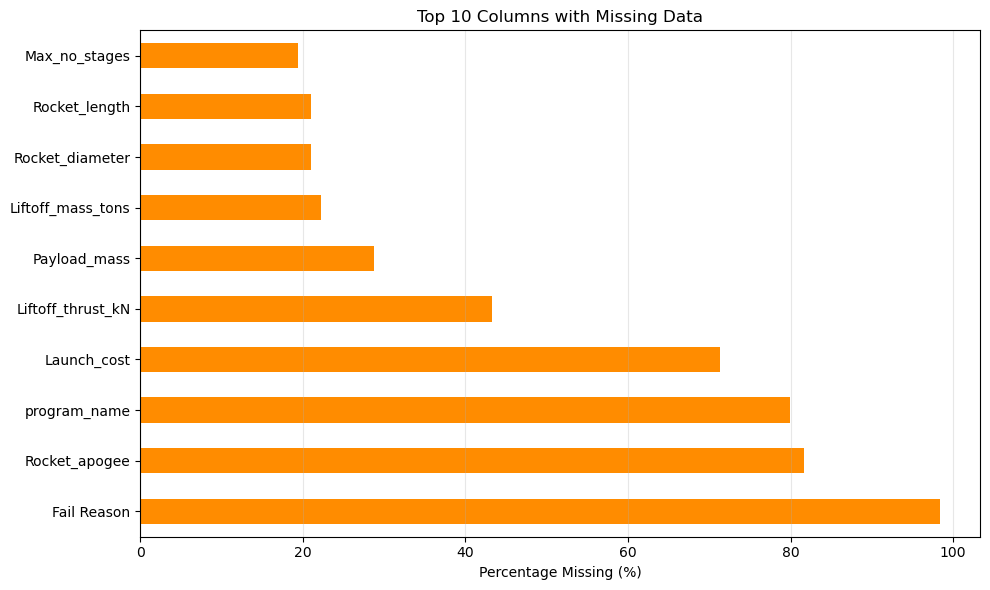

In [12]:
import matplotlib.pyplot as plt

# to store visuals
os.makedirs('figures', exist_ok=True)

# missing percentages
missing_pct = (final_df.isnull().sum() / len(final_df) * 100).sort_values(ascending=False).head(10)

# bar chart
fig, ax = plt.subplots(figsize=(10, 6))
missing_pct.plot(kind='barh', ax=ax, color='darkorange')
ax.set_xlabel('Percentage Missing (%)')
ax.set_title('Top 10 Columns with Missing Data')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()


plt.savefig('figures/data_completeness.png', dpi=150, bbox_inches='tight')
plt.show()

### Historical Launch Timeline Plot

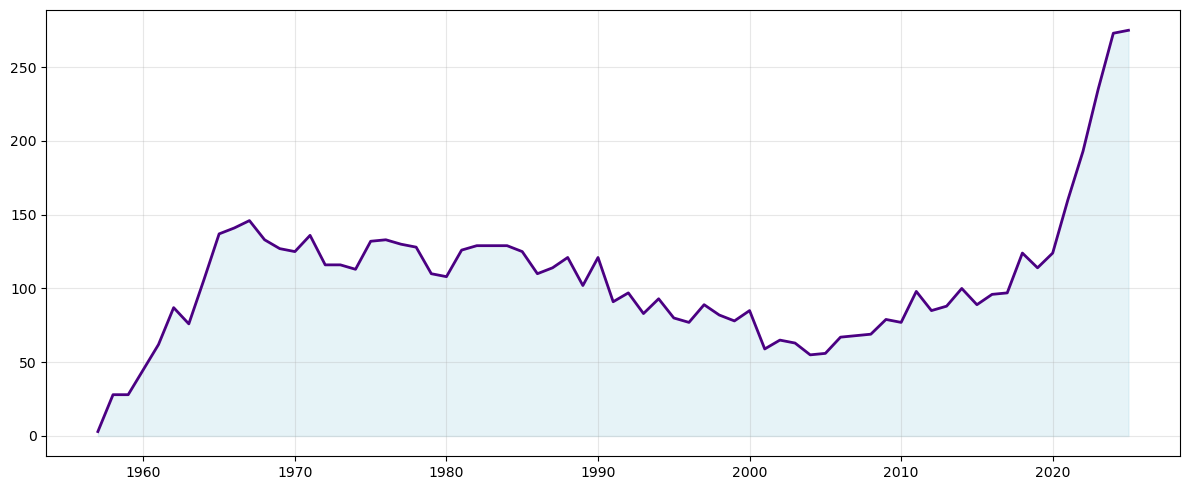

In [13]:
import matplotlib.pyplot as plt

# extract year from launch date
final_df['year'] = pd.to_datetime(final_df['Launch Date']).dt.year

# launches per year
yearly_counts = final_df['year'].value_counts().sort_index()

# line plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yearly_counts.index, yearly_counts.values, linewidth=2, color='indigo')
ax.fill_between(yearly_counts.index, yearly_counts.values, alpha=0.3, color='lightblue')
##ax.set_xlabel('Year')
#ax.set_ylabel('Number of Launches')
#ax.set_title('Complete historical coverage from Sputnik (1957) through 2025')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/temporal_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

### Categorical Breakdown Table

In [14]:

breakdown = pd.DataFrame({
    'Launch Status': final_df['Status'].value_counts(),
    'Top Mission Types': final_df['mission_type'].value_counts().head(5),
    'Top Rocket Families': final_df['Rocket_name'].value_counts().head(5)
})

print(" Dataset Categorical Breakdown:\n")
print("Launch Status Distribution:")
print(final_df['Status'].value_counts().to_markdown())
print("\nTop 5 Mission Types:")
print(final_df['mission_type'].value_counts().head(5).to_markdown())
print("\nTop 5 Most-Used Rockets:")
print(final_df['Rocket_name'].value_counts().head(5).to_markdown())

 Dataset Categorical Breakdown:

Launch Status Distribution:
| Status                       |   count |
|:-----------------------------|--------:|
| Launch Successful            |    6789 |
| Launch Failure               |     513 |
| Launch was a Partial Failure |      34 |

Top 5 Mission Types:
| mission_type          |   count |
|:----------------------|--------:|
| Government/Top Secret |    2253 |
| Communications        |    1570 |
| Earth Science         |     936 |
| Navigation            |     407 |
| Test Flight           |     342 |

Top 5 Most-Used Rockets:
| Rocket_name        |   count |
|:-------------------|--------:|
| Soyuz U            |     714 |
| Falcon 9 Block 5   |     503 |
| Kosmos-3M (11K65M) |     445 |
| Voskhod            |     299 |
| Molniya-M 2BL      |     272 |
